In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import os

# Add work directory to path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
import GWfuncs
import loglikegen

# Import from few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
import few

# Tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu=True
force_backend = 'cuda12x'
# Inspiral kwargs
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

# Amplitude kwargs
amplitude_kwargs = {
    "force_backend": force_backend
}

# Ylm kwargs
Ylm_kwargs = {
    "force_backend": force_backend,
}

# Sum kwargs
sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

# Create waveform generators
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)



In [70]:
# True parameters (same as notebook)
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4
xI0 = 1.0
dist = 0.25
qS = 0.5
phiS = 1
qK = 1
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

In [71]:
# 1 mth
T = 1/12 
dt = 10
gwf = GWfuncs.GravWaveAnalysis(T, dt)
mode_select = [(2, -2, 0), (2, -2, -1), (2, -2, 1), (3, -3, -1), (3, -3, 1)]
print("Initializing loglike class...")
loglike_obj = loglikegen.LogLike(params_star,
                                    waveform_gen_comb,
                                    gwf,
                                    mode_select=mode_select,
                                    verbose=False,
                                    waveform_gen_sep=waveform_gen_sep)

Initializing loglike class...


In [72]:
def standard_lnL(params, data, gwf, waveform_gen_comb,
                 xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0):
    """
    Calculate standard log-likelihood: -0.5*<d-h|d-h>

    Parameters:
    -----------
    params : array-like
        [logm1, logm2, a, p0, e0]
    data_fd : array
        Frequency domain data
    gwf : GravWaveAnalysis object
        GW analysis object with inner product method
    waveform_gen_comb : waveform generator
        Combined waveform generator
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 : float
        Fixed parameters

    Returns:
    --------
    lnL : float
        Standard log-likelihood value
    """
    params = np.asarray(params)

    def eval_one(x):
        try:
            logm1, logm2, a, p0, e0 = x
            m1 = 10**logm1
            m2 = 10**logm2

            # Generate full combined template waveform
            template_td = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist,
                                             qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
                                             T=gwf.T, dt=gwf.dt)


            # Compute residual
            residual = data - template_td
            residual_fd = gwf.freq_wave(residual)

            # Compute -0.5*<d-h|d-h>
            lnL = -0.5 * gwf.inner(residual_fd, residual_fd)

            return lnL
        except Exception as e:
            print(f"Error in standard_lnL: {e}")
            return float('-inf')

    if params.ndim == 1:
        return eval_one(params)

    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

In [73]:
def fstat(params, loglike_obj, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0):
    """
    Calculate F-statistic for given parameters.

    Parameters:
    -----------
    params : array-like
        [logm1, logm2, a, p0, e0]
    loglike_obj : LogLike object
        Initialized log-likelihood object
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 : float
        Fixed parameters

    Returns:
    --------
    fstat : float
        F-statistic value (returns log-likelihood, NOT 2*log-likelihood)
    """
    params = np.asarray(params)

    def eval_one(x):
        try:
            logm1, logm2, a, p0, e0 = x
            m1 = 10**logm1
            m2 = 10**logm2

            fstat_val = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
            return fstat_val
        except Exception:
            return float('-inf')

    if params.ndim == 1:
        return eval_one(params)

    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

In [74]:
cov_matrix_path='localgit/FEWNEW/work/search/cov_matrix_2yr.pkl'
with open(cov_matrix_path, 'rb') as f:
    cov_matrix = pickle.load(f)

In [75]:
data_fd = np.fft.rfft(loglike_obj.signal)
data_fd

/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/cupy/fft/_fft.py:35: ComplexWarning: Casting complex values to real discards the imaginary part
  a = a.astype(out_dtype)


array([ 1.85148616e-21+0.00000000e+00j,  1.85149461e-21-1.21448717e-23j,
        1.85151998e-21-2.42901158e-23j, ...,
       -1.65998591e-22+5.58705402e-27j, -1.65998590e-22+3.35191557e-27j,
       -1.65998590e-22+1.11724649e-27j])

In [76]:
gwf_2yr = GWfuncs.GravWaveAnalysis(T=2, dt=10)
loglike_obj_2yr = loglikegen.LogLike(params_star,
                                    waveform_gen_comb,
                                    gwf_2yr,
                                    mode_select=mode_select,
                                    verbose=False,
                                    waveform_gen_sep=waveform_gen_sep)

In [107]:
param_idx = 1 # logm2
true_val = param_true[param_idx]
sigma = np.sqrt(cov_matrix[param_idx, param_idx])
n_sigma = 150
n_points = 100
param_range = np.linspace(true_val - n_sigma*sigma, true_val + n_sigma*sigma, n_points)
param_range = np.append(param_range, true_val)
param_range = np.sort(param_range)

# Arrays to store results
f_stats = np.zeros(len(param_range))
lnL_vals = np.zeros(len(param_range))


# Unpack params_star
m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

for i, val in enumerate(param_range):
    # Build parameter array [logm1, logm2, a, p0, e0]
    param_arr = param_true.copy()
    param_arr[param_idx] = val

    # Calculate F-statistic using fstat function
    fstat_val = fstat(param_arr, loglike_obj, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
    f_stats[i] = fstat_val
    # Calculate standard log-likelihood
    lnL_val = standard_lnL(param_arr, loglike_obj_2yr.signal, gwf_2yr, waveform_gen_comb,
                            xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
    lnL_vals[i] = lnL_val

In [108]:
# Normalize computed F-stat to peak at 0
f_stats_norm = f_stats - np.max(f_stats)
lnL_norm = lnL_vals - np.max(lnL_vals)

In [109]:
np.min(f_stats_norm), np.min(lnL_norm)

(-3.8440453566929027, -978.694874682033)

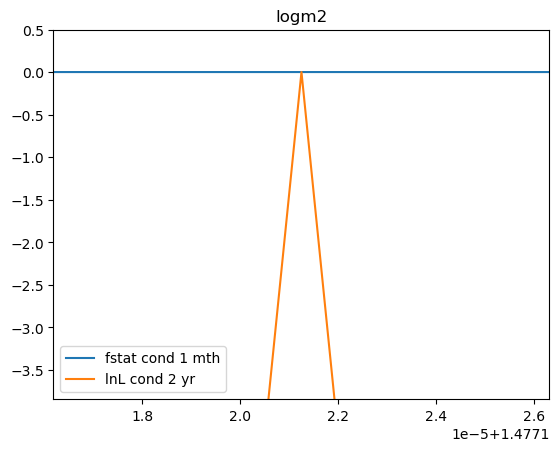

In [115]:
plt.plot(param_range, f_stats_norm, label='fstat cond 1 mth')
plt.plot(param_range, lnL_vals, label='lnL cond 2 yr')
# plt.axvline(param_range[88], color='k', linestyle='--', label='Drop fstat')
plt.ylim(np.min(f_stats_norm), 0.5)
plt.xlim(true_val - 0.05*sigma, true_val + 0.05*sigma)
plt.title('logm2')
plt.legend()
plt.show()

In [62]:
param_range[np.argmax(lnL_vals)]-param_range[np.argmax(lnL_vals)-1]

0.00015360369535932783

In [67]:
param_range[np.argmax(f_stats_norm)]--param_range[-1]

2.9694492752799064

In [68]:
2.9694492752799064/0.00015360369535932783


19331.886959707717

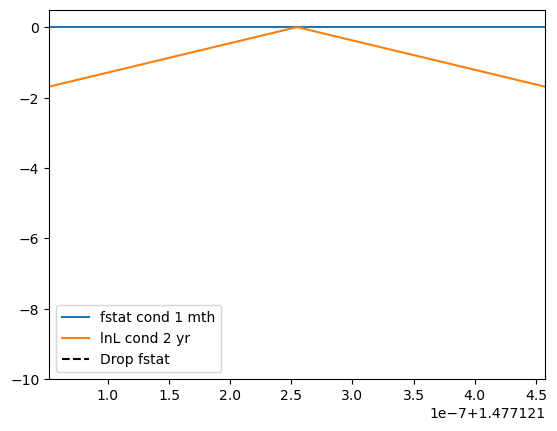

In [56]:
plt.plot(param_range, f_stats_norm, label='fstat cond 1 mth')
plt.plot(param_range, lnL_vals, label='lnL cond 2 yr')
plt.axvline(param_range[88], color='k', linestyle='--', label='Drop fstat')
plt.ylim(-10, 0.5)
plt.xlim(true_val - 2e-3*sigma, true_val + 2e-3*sigma)
plt.legend()
plt.show()

In [103]:
# Calculate weighted mean
mean_lnL = np.average(param_range, weights=np.exp(lnL_norm))
# Calculate weighted variance
var_lnL = np.average((param_range - mean_lnL)**2, weights=np.exp(lnL_norm))
std_lnL = np.sqrt(var_lnL)
std_lnL

1.1460614291931218e-69

In [105]:
# Calculate weighted mean
mean_fstat = np.average(param_range, weights=np.exp(f_stats_norm))
# Calculate weighted variance
var_fstat = np.average((param_range - mean_fstat)**2, weights=np.exp(f_stats_norm))
std_fstat = np.sqrt(var_fstat)
std_fstat

7.980017660825608e-06

In [106]:
std_lnL / std_fstat

1.4361640260762919e-64

In [107]:
np.std(lnL_vals)/np.std(f_stats_norm)

64.8691093378984

In [109]:
param_proc1 = np.array([6.02680358,  1.46982606,  0.7897165 , 14.39679547,  0.39827987])

In [114]:
standard_lnL(param_proc1, loglike_obj_2yr.signal, gwf_2yr, waveform_gen_comb,
                 xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

array(-899.48041725)

In [113]:
standard_lnL(param_true, loglike_obj_2yr.signal, gwf_2yr, waveform_gen_comb,
                 xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

array(-2.78966634e-17)

In [116]:
param_proc2 = np.array([5.93845955,  1.50506177,  0.45790577, 16.56223858,  0.39802901])

In [117]:
standard_lnL(param_proc2, loglike_obj_2yr.signal, gwf_2yr, waveform_gen_comb,
                 xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

array(-810.49990359)

In [118]:
fstat(param_true, loglike_obj, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0) 

5.283211883512379

In [119]:
fstat(param_proc1, loglike_obj, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

5.279872435237045

In [120]:
fstat(param_proc2, loglike_obj, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

5.276279650494321